# 02 — Exploratory Data Analysis

This notebook explores the cleaned COPD dataset before feature engineering and predictive modelling.

The analysis focuses on:

- the distribution of daily COPD-related emergency department visits;
- the binary response indicating whether at least one visit occurred;
- temporal patterns by weekday, month and year;
- differences by sex and age group;
- distributions and temporal behaviour of air-pollution variables;
- distributions and temporal behaviour of meteorological variables;
- statistical associations and correlations between environmental variables.

Only environmental variables corresponding to the day of exposure (`LAG0`) are used for descriptive environmental analyses, since the remaining lagged variables contain the same underlying time series shifted in time.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from scipy.stats import (
    spearmanr,
    kruskal,
    mannwhitneyu,
    chi2_contingency,
)

from statsmodels.stats.multitest import multipletests

from copd_forecasting.config import (
    PROCESSED_DATA_FILE,
    DATE_COLUMN,
)

## 1. Load cleaned dataset

The exploratory analysis uses the cleaned dataset generated in the previous notebook after temporal-boundary removal, data-quality checks and missing-value imputation.

In [2]:
df = pd.read_excel(
    PROCESSED_DATA_FILE,
    parse_dates=[DATE_COLUMN],
)

df = (
    df
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

print(
    f"Dataset shape: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)

print(
    f"Date range: "
    f"{df[DATE_COLUMN].min().date()} → "
    f"{df[DATE_COLUMN].max().date()}"
)

print(
    f"Missing values: "
    f"{df.isna().sum().sum():,}"
)

Dataset shape: 5,106 rows × 187 columns
Date range: 2010-01-08 → 2023-12-31
Missing values: 0


In [3]:
# Healthcare variables
SEX_VISIT_COLS = [
    "n_urgencias_H",
    "n_urgencias_M",
]

AGE_VISIT_COLS = [
    "n_urgencias_menos_65",
    "n_urgencias_mas_65",
]

# Air-pollution variables
POLLUTION_VARS = [
    "PM10",
    "PM2p5",
    "NO",
    "NO2",
    "CO",
    "O3",
]

# Meteorological variables
METEOROLOGICAL_VARS = [
    "temp_min",
    "temp_med",
    "temp_max",
    "temp_sens",
    "pres_min",
    "pres_med",
    "pres_max",
    "prec_24",
    "sol_24",
    "vel_med",
    "vel_max",
    "hume_med",
    "hume_max",
]

POLLUTION_LAG0_COLS = [
    f"{var}_LAG0"
    for var in POLLUTION_VARS
    if f"{var}_LAG0" in df.columns
]

METEOROLOGICAL_LAG0_COLS = [
    f"{var}_LAG0"
    for var in METEOROLOGICAL_VARS
    if f"{var}_LAG0" in df.columns
]

print(
    f"Pollution variables (LAG0): "
    f"{len(POLLUTION_LAG0_COLS)}"
)

print(
    f"Meteorological variables (LAG0): "
    f"{len(METEOROLOGICAL_LAG0_COLS)}"
)

Pollution variables (LAG0): 6
Meteorological variables (LAG0): 13


In [4]:
df["year"] = df[DATE_COLUMN].dt.year
df["month"] = df[DATE_COLUMN].dt.month
df["weekday"] = df[DATE_COLUMN].dt.dayofweek

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec",
]

WEEKDAY_LABELS = [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun",
]

## 2. Daily COPD emergency department visits

The original response variable is the daily number of emergency department visits associated with COPD exacerbations.

Its distribution is examined before converting the forecasting problem into binary classification.

In [5]:
def descriptive_summary(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """Return the main descriptive statistics used in the study."""

    summary = dataframe[columns].describe().T

    summary["IQR"] = (
        summary["75%"]
        - summary["25%"]
    )

    summary = summary.rename(
        columns={
            "mean": "Mean",
            "std": "SD",
            "50%": "Median",
            "min": "Min",
            "max": "Max",
        }
    )

    return summary[
        [
            "Mean",
            "SD",
            "Median",
            "IQR",
            "Min",
            "Max",
        ]
    ]

In [6]:
visit_summary = descriptive_summary(
    df,
    ["n_urgencias"],
)

visit_summary.round(3)

,Mean,SD,Median,IQR,Min,Max
n_urgencias,0.861,0.996,1.0,1.0,0.0,6.0


### Binary response

For predictive modelling, the daily count is transformed into a binary target:

- `0`: no COPD-related emergency visit;
- `1`: at least one COPD-related emergency visit.

This formulation converts the original count problem into a daily occurrence classification task.

In [7]:
df["target"] = (
    df["n_urgencias"] >= 1
).astype(int)

n_positive = int(df["target"].sum())
n_negative = len(df) - n_positive
positive_rate = df["target"].mean() * 100

print(
    f"Days without visits: "
    f"{n_negative:,} "
    f"({100 - positive_rate:.1f}%)"
)

print(
    f"Days with ≥1 visit: "
    f"{n_positive:,} "
    f"({positive_rate:.1f}%)"
)

Days without visits: 2,308 (45.2%)
Days with ≥1 visit: 2,798 (54.8%)


## 3. Distribution of the response variables

The daily emergency-visit count is strongly concentrated at low values. The binary transformation provides a simpler representation of daily healthcare demand by distinguishing between days with and without at least one COPD-related emergency visit.

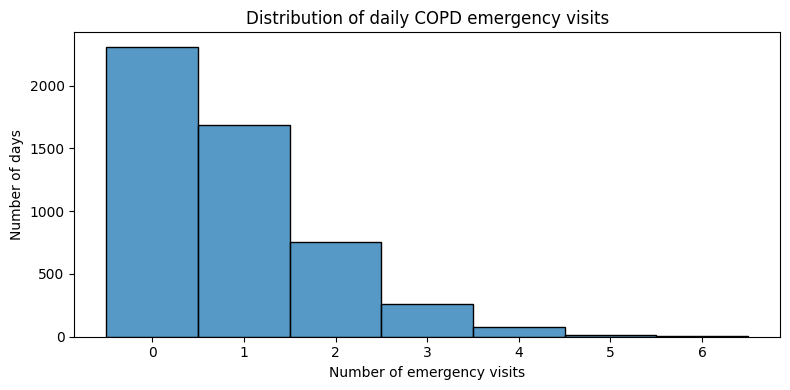

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=df,
    x="n_urgencias",
    discrete=True,
    ax=ax,
)

ax.set_title("Distribution of daily COPD emergency visits")
ax.set_xlabel("Number of emergency visits")
ax.set_ylabel("Number of days")

plt.tight_layout()
plt.show()

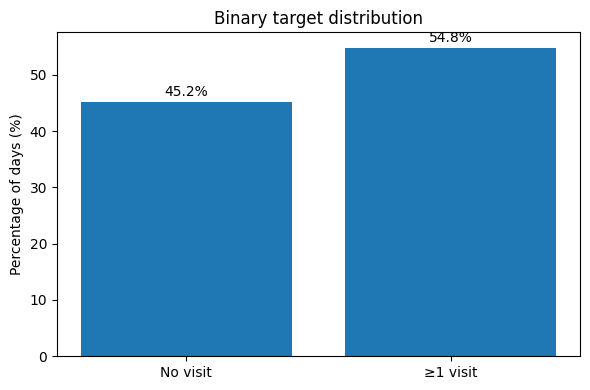

In [9]:
target_distribution = (
    df["target"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    target_distribution
    / len(df)
    * 100
)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["No visit", "≥1 visit"],
    target_percentages.values,
)

ax.set_title("Binary target distribution")
ax.set_ylabel("Percentage of days (%)")

for i, value in enumerate(target_percentages.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
    )

plt.tight_layout()
plt.show()

## 4. Temporal evolution of COPD emergency visits

Daily values are highly variable, making long-term patterns difficult to identify directly.

A 30-day centred moving average is therefore used for the daily visit count, while a 90-day moving average is used for the binary response to visualise changes in the proportion of positive days over time.

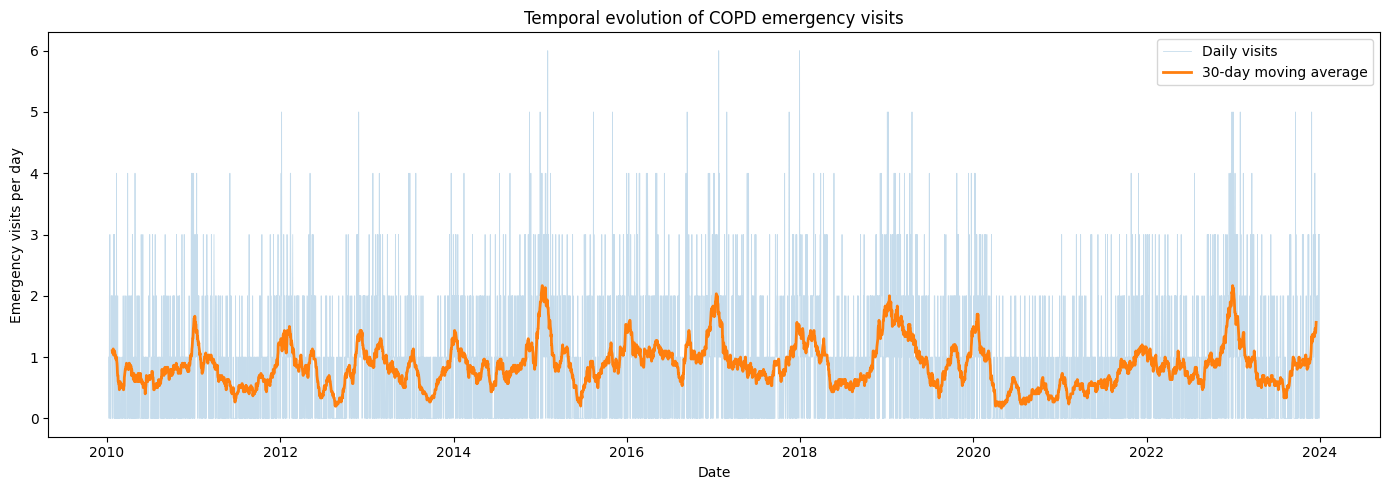

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df[DATE_COLUMN],
    df["n_urgencias"],
    alpha=0.25,
    linewidth=0.6,
    label="Daily visits",
)

ax.plot(
    df[DATE_COLUMN],
    df["n_urgencias"]
    .rolling(30, center=True)
    .mean(),
    linewidth=2,
    label="30-day moving average",
)

ax.set_title("Temporal evolution of COPD emergency visits")
ax.set_xlabel("Date")
ax.set_ylabel("Emergency visits per day")
ax.legend()

plt.tight_layout()
plt.show()

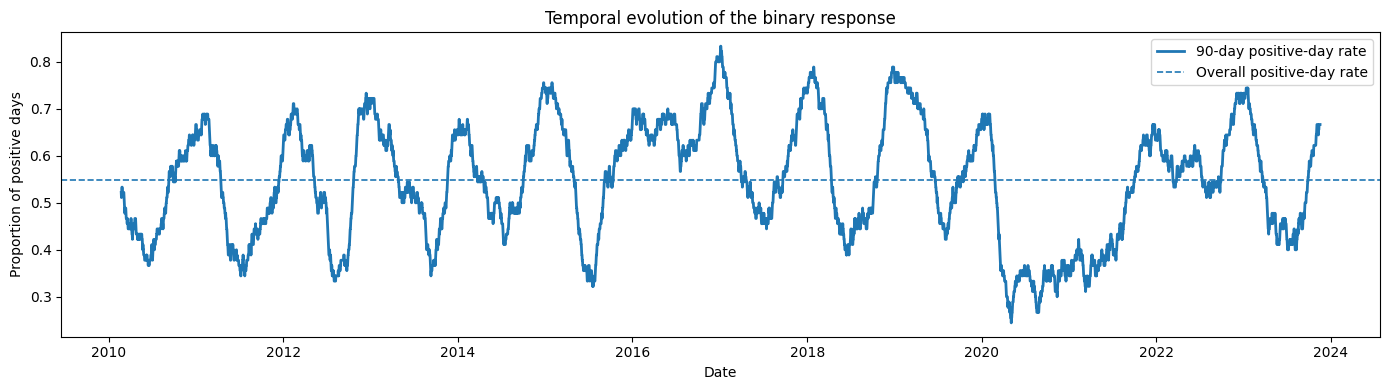

In [11]:
target_rolling = (
    df
    .set_index(DATE_COLUMN)["target"]
    .rolling(90, center=True)
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    target_rolling.index,
    target_rolling,
    linewidth=2,
    label="90-day positive-day rate",
)

ax.axhline(
    df["target"].mean(),
    linestyle="--",
    linewidth=1.2,
    label="Overall positive-day rate",
)

ax.set_title("Temporal evolution of the binary response")
ax.set_xlabel("Date")
ax.set_ylabel("Proportion of positive days")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Seasonal patterns

Monthly and weekly aggregation is used to explore recurring temporal patterns in COPD-related emergency demand.

Both the mean daily number of visits and the proportion of positive days are examined.

In [12]:
monthly_summary = (
    df
    .groupby("month")
    .agg(
        mean_visits=("n_urgencias", "mean"),
        positive_rate=("target", "mean"),
    )
)

weekly_summary = (
    df
    .groupby("weekday")
    .agg(
        mean_visits=("n_urgencias", "mean"),
        positive_rate=("target", "mean"),
    )
)

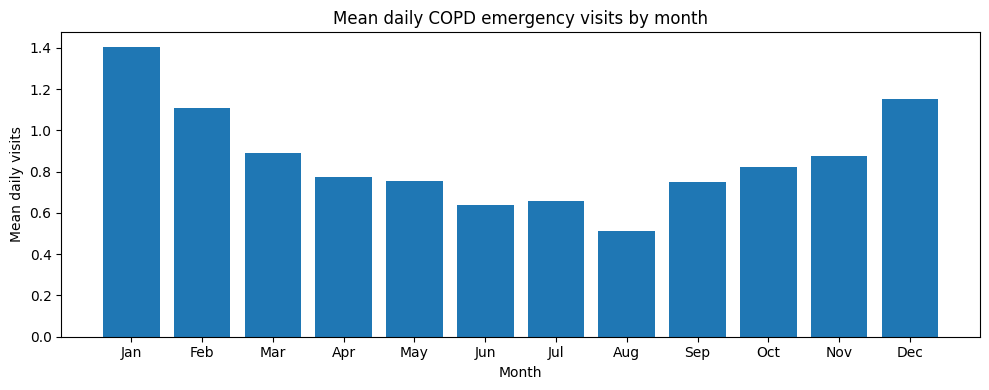

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    MONTH_LABELS,
    monthly_summary["mean_visits"],
)

ax.set_title("Mean daily COPD emergency visits by month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily visits")

plt.tight_layout()
plt.show()

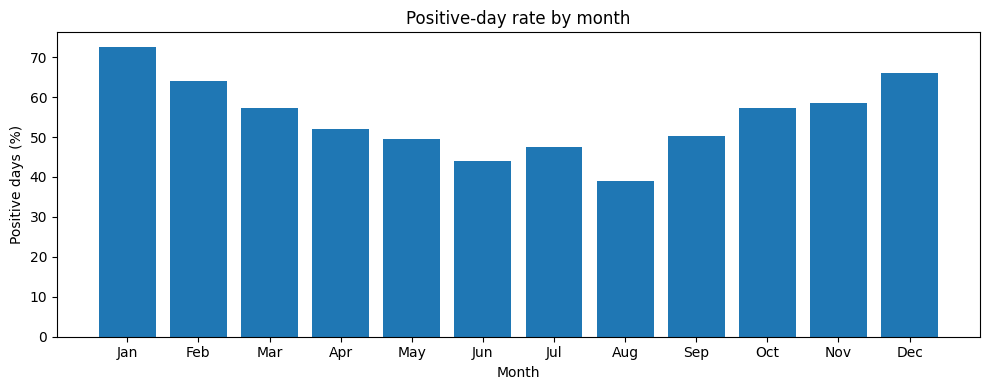

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    MONTH_LABELS,
    monthly_summary["positive_rate"] * 100,
)

ax.set_title("Positive-day rate by month")
ax.set_xlabel("Month")
ax.set_ylabel("Positive days (%)")

plt.tight_layout()
plt.show()

## 6. Weekly patterns

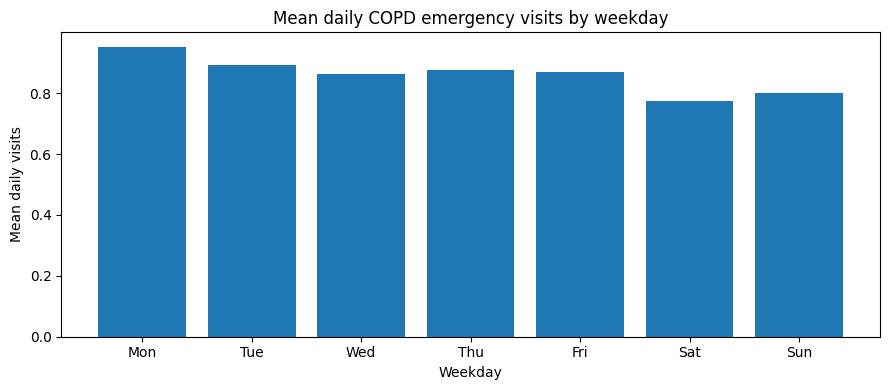

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    WEEKDAY_LABELS,
    weekly_summary["mean_visits"],
)

ax.set_title("Mean daily COPD emergency visits by weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Mean daily visits")

plt.tight_layout()
plt.show()

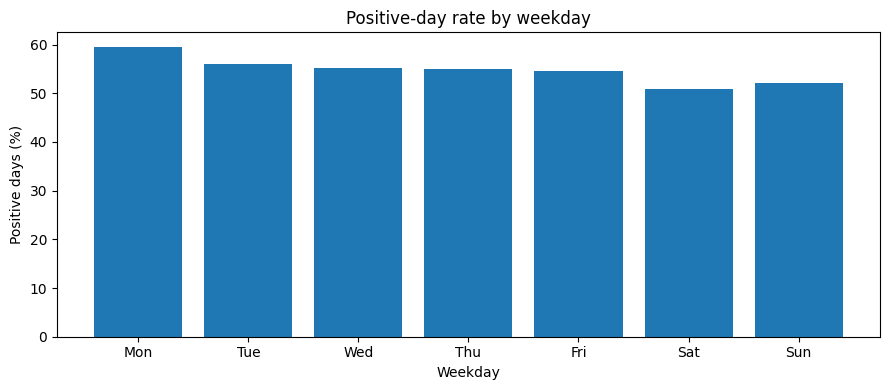

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    WEEKDAY_LABELS,
    weekly_summary["positive_rate"] * 100,
)

ax.set_title("Positive-day rate by weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Positive days (%)")

plt.tight_layout()
plt.show()

## 7. Interannual evolution

Annual aggregation is used to examine longer-term variation in COPD-related emergency demand across the study period.

In [17]:
annual_summary = (
    df
    .groupby("year")
    .agg(
        mean_visits=("n_urgencias", "mean"),
        positive_rate=("target", "mean"),
    )
    .reset_index()
)

annual_summary["positive_rate"] *= 100

annual_summary.round(3)

,year,mean_visits,positive_rate
0,2010,0.749,50.000
1,2011,0.712,49.589
2,2012,0.831,56.284
3,2013,0.770,53.425
4,2014,0.893,56.164
5,2015,0.956,55.890
6,2016,1.107,67.213
7,2017,0.978,59.726
8,2018,0.901,57.534
9,2019,1.082,61.370


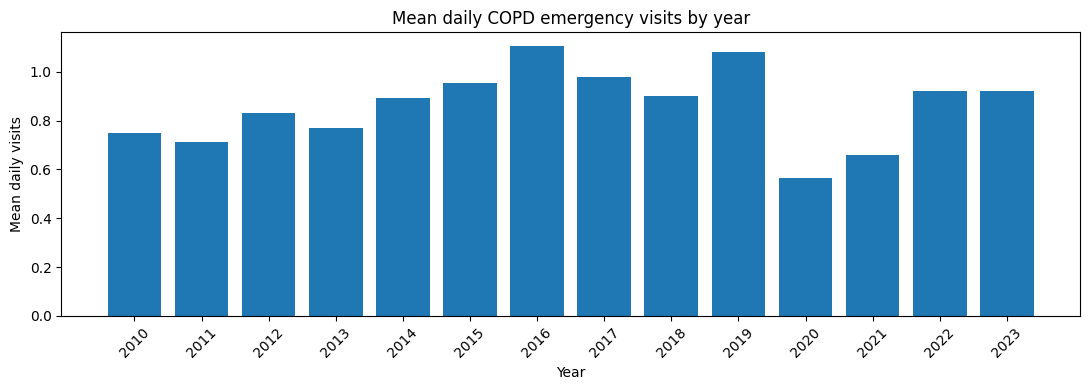

In [18]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.bar(
    annual_summary["year"],
    annual_summary["mean_visits"],
)

ax.set_title("Mean daily COPD emergency visits by year")
ax.set_xlabel("Year")
ax.set_ylabel("Mean daily visits")
ax.set_xticks(annual_summary["year"])
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

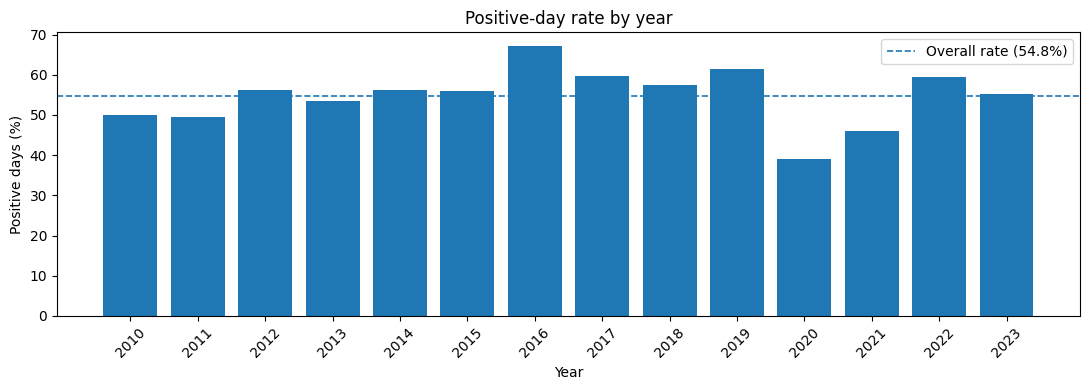

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.bar(
    annual_summary["year"],
    annual_summary["positive_rate"],
)

ax.axhline(
    positive_rate,
    linestyle="--",
    linewidth=1.2,
    label=f"Overall rate ({positive_rate:.1f}%)",
)

ax.set_title("Positive-day rate by year")
ax.set_xlabel("Year")
ax.set_ylabel("Positive days (%)")
ax.set_xticks(annual_summary["year"])
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
annual_summary.loc[
    annual_summary["positive_rate"].idxmin()
]

year             2020.000000
mean_visits         0.565574
positive_rate      39.071038
Name: 10, dtype: float64

## 8. Stratified analysis by sex and age

Daily COPD-related emergency visits are also explored across population subgroups.

The analysis compares:

- men vs. women;
- patients younger than 65 years vs. patients aged 65 years or older.

These stratified variables are used only for descriptive purposes and are not included as predictors in the machine-learning models.

In [21]:
STRATIFIED_LABELS = {
    "n_urgencias_H": "Men",
    "n_urgencias_M": "Women",
    "n_urgencias_menos_65": "<65 years",
    "n_urgencias_mas_65": "≥65 years",
}

stratified_cols = [
    col
    for col in (
        SEX_VISIT_COLS
        + AGE_VISIT_COLS
    )
    if col in df.columns
]

stratified_summary = descriptive_summary(
    df,
    stratified_cols,
)

stratified_summary = stratified_summary.rename(
    index=STRATIFIED_LABELS
)

stratified_summary.round(3)

,Mean,SD,Median,IQR,Min,Max
Men,0.696,0.888,0.0,1.0,0.0,5.0
Women,0.165,0.422,0.0,0.0,0.0,3.0
<65 years,0.128,0.366,0.0,0.0,0.0,4.0
≥65 years,0.732,0.907,0.0,1.0,0.0,5.0


### Distribution across population subgroups

The distributions are highly concentrated at zero, particularly among women and patients younger than 65 years.

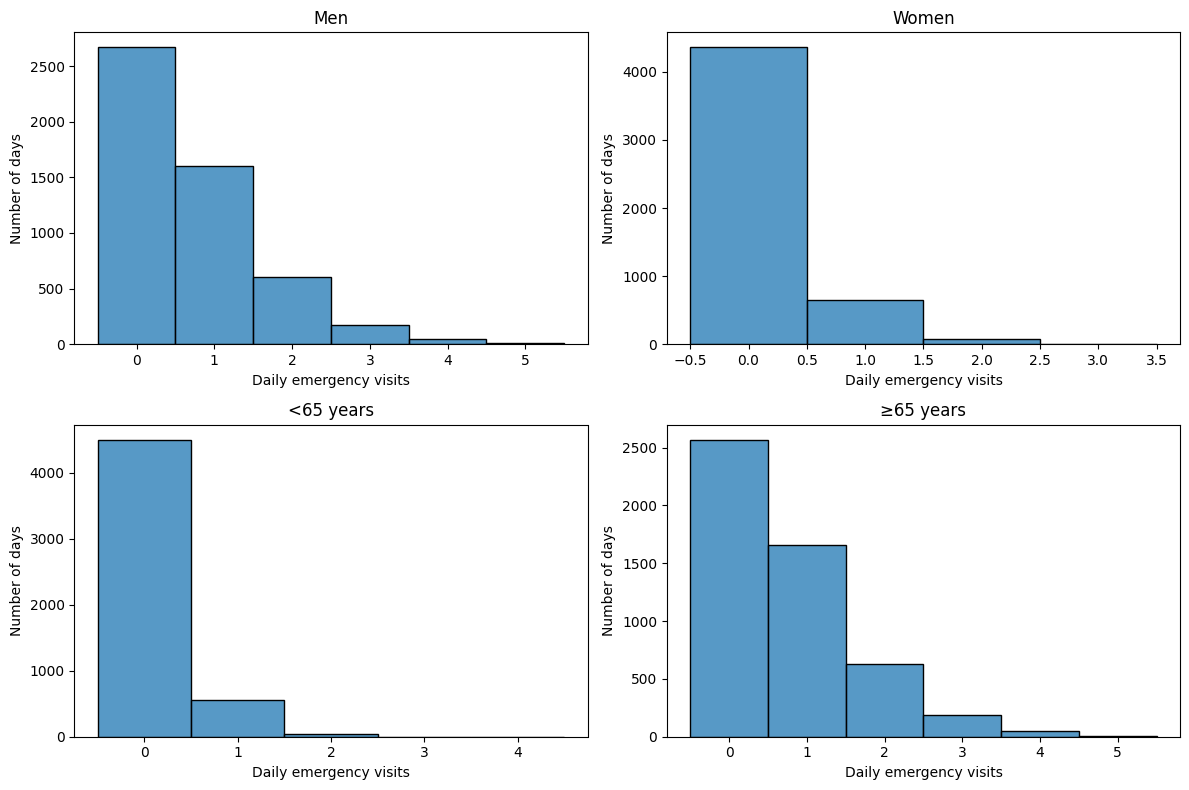

In [22]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes = axes.flatten()

for ax, col in zip(
    axes,
    stratified_cols,
):
    sns.histplot(
        data=df,
        x=col,
        discrete=True,
        ax=ax,
    )

    ax.set_title(
        STRATIFIED_LABELS[col]
    )
    ax.set_xlabel(
        "Daily emergency visits"
    )
    ax.set_ylabel(
        "Number of days"
    )

plt.tight_layout()
plt.show()

## 9. Daily presence of visits by subgroup

In [23]:
subgroup_positive_rates = pd.Series(
    {
        STRATIFIED_LABELS[col]:
        (df[col] >= 1).mean() * 100

        for col in stratified_cols
    },
    name="Positive days (%)",
)

subgroup_positive_rates.round(1)

Men          47.7
Women        14.6
<65 years    11.8
≥65 years    49.7
Name: Positive days (%), dtype: float64

## 10. Chi-square tests for subgroup differences

For each subgroup, the daily visit count is binarised using the same criterion as the main response:

- `0`: no visits;
- `1`: at least one visit.

Chi-square tests are then used to explore differences in the frequency of positive and negative days between sex and age groups.

In [24]:
sex_contingency = pd.DataFrame(
    {
        "No visit": [
            (df["n_urgencias_H"] == 0).sum(),
            (df["n_urgencias_M"] == 0).sum(),
        ],
        "≥1 visit": [
            (df["n_urgencias_H"] >= 1).sum(),
            (df["n_urgencias_M"] >= 1).sum(),
        ],
    },
    index=[
        "Men",
        "Women",
    ],
)

sex_contingency

,No visit,≥1 visit
Men,2670,2436
Women,4362,744


In [25]:
chi2_sex, p_sex, dof_sex, _ = (
    chi2_contingency(
        sex_contingency
    )
)

print(
    f"Sex: "
    f"χ² = {chi2_sex:.3f} | "
    f"df = {dof_sex} | "
    f"p = {p_sex:.4g}"
)

Sex: χ² = 1305.846 | df = 1 | p = 6.064e-286


In [26]:
age_contingency = pd.DataFrame(
    {
        "No visit": [
            (
                df["n_urgencias_menos_65"]
                == 0
            ).sum(),
            (
                df["n_urgencias_mas_65"]
                == 0
            ).sum(),
        ],
        "≥1 visit": [
            (
                df["n_urgencias_menos_65"]
                >= 1
            ).sum(),
            (
                df["n_urgencias_mas_65"]
                >= 1
            ).sum(),
        ],
    },
    index=[
        "<65 years",
        "≥65 years",
    ],
)

age_contingency

,No visit,≥1 visit
<65 years,4503,603
≥65 years,2569,2537


In [27]:
chi2_age, p_age, dof_age, _ = (
    chi2_contingency(
        age_contingency
    )
)

print(
    f"Age: "
    f"χ² = {chi2_age:.3f} | "
    f"df = {dof_age} | "
    f"p = {p_age:.4g}"
)

Age: χ² = 1718.314 | df = 1 | p = 0


## 11. Temporal evolution by population subgroup

Thirty-day moving averages are used to compare the temporal evolution of daily visits across sex and age groups.

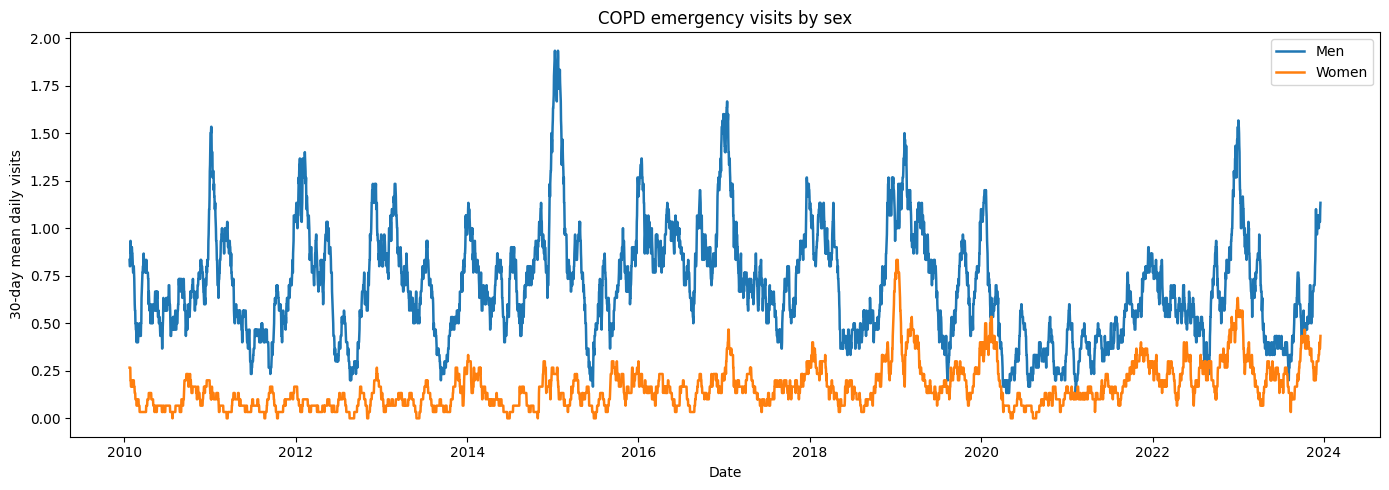

In [28]:
fig, ax = plt.subplots(
    figsize=(14, 5)
)

for col in SEX_VISIT_COLS:
    ax.plot(
        df[DATE_COLUMN],
        df[col]
        .rolling(30, center=True)
        .mean(),
        linewidth=1.8,
        label=STRATIFIED_LABELS[col],
    )

ax.set_title(
    "COPD emergency visits by sex"
)
ax.set_xlabel("Date")
ax.set_ylabel(
    "30-day mean daily visits"
)
ax.legend()

plt.tight_layout()
plt.show()

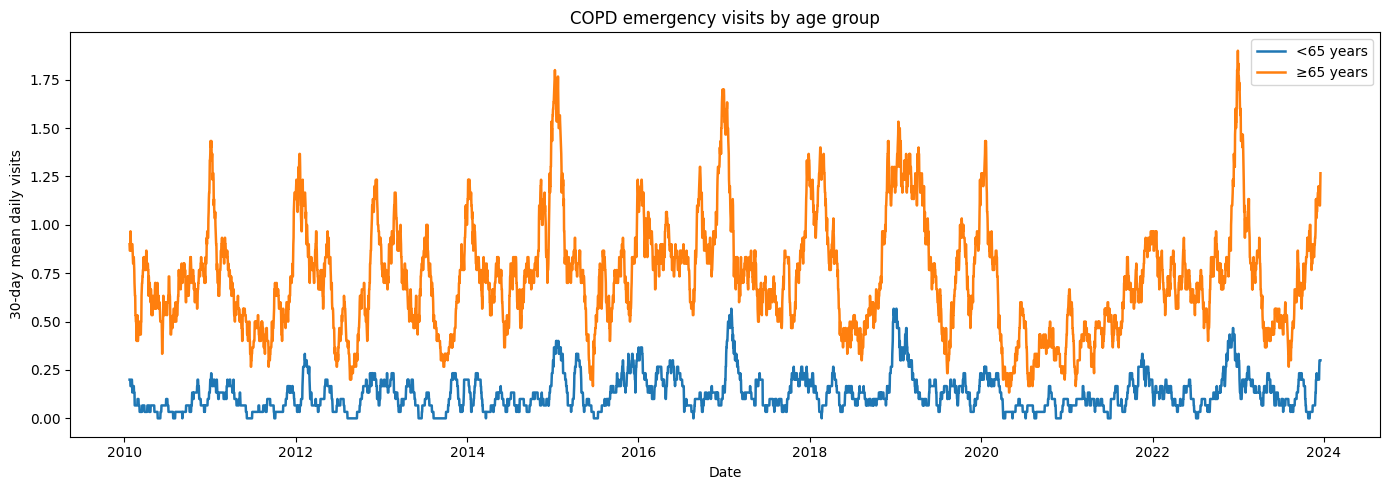

In [29]:
fig, ax = plt.subplots(
    figsize=(14, 5)
)

for col in AGE_VISIT_COLS:
    ax.plot(
        df[DATE_COLUMN],
        df[col]
        .rolling(30, center=True)
        .mean(),
        linewidth=1.8,
        label=STRATIFIED_LABELS[col],
    )

ax.set_title(
    "COPD emergency visits by age group"
)
ax.set_xlabel("Date")
ax.set_ylabel(
    "30-day mean daily visits"
)
ax.legend()

plt.tight_layout()
plt.show()

## 12. Air-pollution variables

Air-pollution variables are explored using their same-day exposure values (`LAG0`).

For each pollutant, the analysis includes:

- descriptive statistics;
- comparison between days with and without COPD-related emergency visits;
- distribution of daily concentrations;
- temporal evolution;
- monthly patterns.

PM10, PM2.5, NO, NO2 and O3 are expressed in µg/m³, while CO is expressed in mg/m³.

In [30]:
POLLUTION_LABELS = {
    "PM10_LAG0": "PM10",
    "PM2p5_LAG0": "PM2.5",
    "NO_LAG0": "NO",
    "NO2_LAG0": "NO2",
    "CO_LAG0": "CO",
    "O3_LAG0": "O3",
}

In [31]:
pollution_summary = descriptive_summary(
    df,
    POLLUTION_LAG0_COLS,
)

pollution_summary = pollution_summary.rename(
    index=POLLUTION_LABELS
)

mannwhitney_results = {}

for col in POLLUTION_LAG0_COLS:
    group_negative = df.loc[
        df["target"] == 0,
        col,
    ]

    group_positive = df.loc[
        df["target"] == 1,
        col,
    ]

    statistic, p_value = mannwhitneyu(
        group_negative,
        group_positive,
        alternative="two-sided",
    )

    mannwhitney_results[
        POLLUTION_LABELS[col]
    ] = p_value

pollution_summary["p_value"] = pd.Series(
    mannwhitney_results
)

pollution_summary.round(4)

,Mean,SD,Median,IQR,Min,Max,p_value
PM10,17.3424,11.4413,15.0,11.7,1.0,358.6,0.1040
PM2.5,11.0765,6.3531,9.5,7.5,1.3,87.3,0.0721
NO,11.4075,14.2077,6.3,9.1,1.0,147.0,0.0000
NO2,21.2800,10.8461,19.2,14.5,1.7,76.3,0.0000
CO,0.3023,0.2283,0.3,0.3,0.1,5.3,0.0000
O3,51.2156,20.7534,54.3,29.0,1.0,114.3,0.0000


In [32]:
pollution_summary[
    "Significant"
] = (
    pollution_summary["p_value"]
    < 0.05
)

pollution_summary[
    ["p_value", "Significant"]
]

,p_value,Significant
PM10,1.039998e-01,False
PM2.5,7.214345e-02,False
NO,1.026441e-11,True
NO2,1.176419e-07,True
CO,3.535903e-07,True
O3,1.031481e-13,True


## 13. Pollutant distributions

Most pollutant distributions are right-skewed, with observations concentrated at low or intermediate values and relatively few high-concentration episodes.

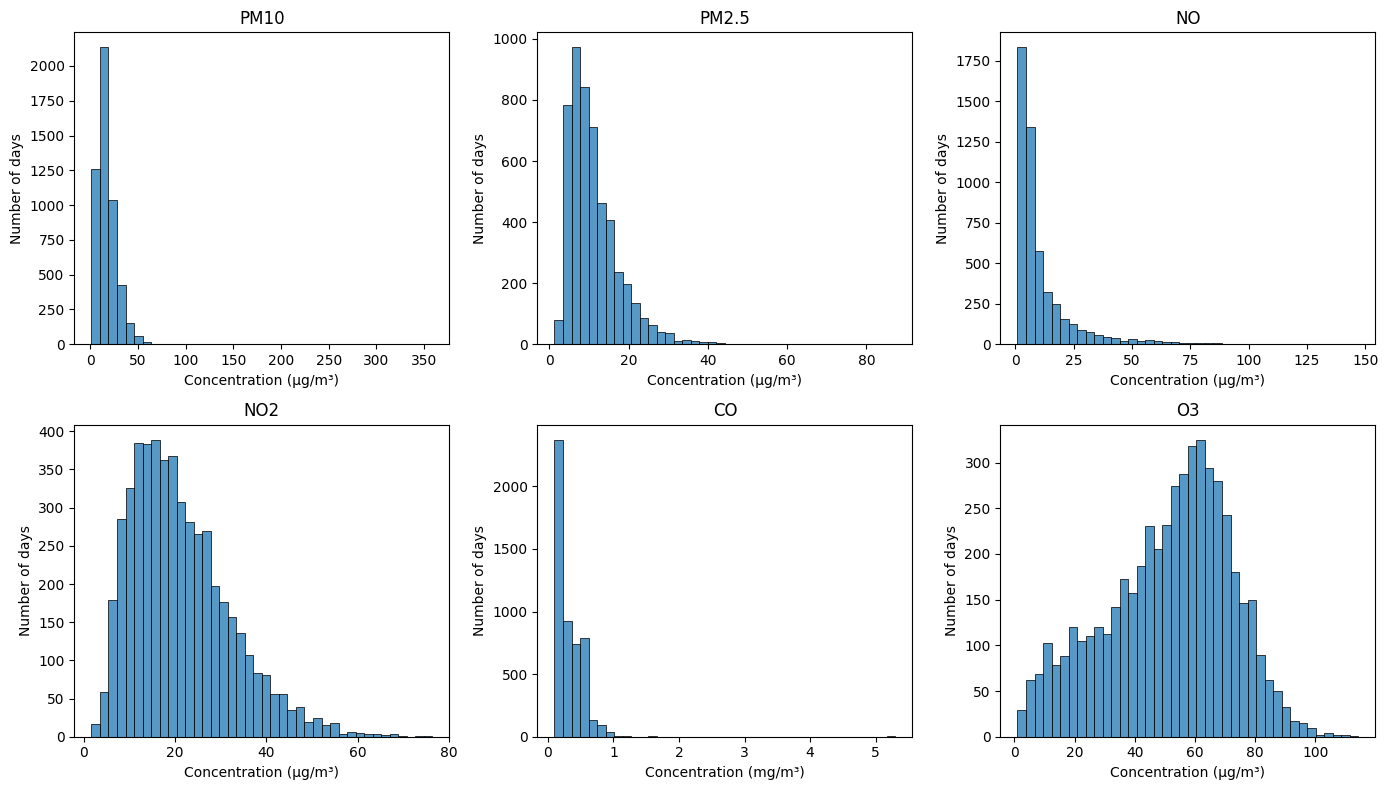

In [33]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

axes = axes.flatten()

for ax, col in zip(
    axes,
    POLLUTION_LAG0_COLS,
):
    sns.histplot(
        data=df,
        x=col,
        bins=40,
        ax=ax,
    )

    unit = (
        "mg/m³"
        if col == "CO_LAG0"
        else "µg/m³"
    )

    ax.set_title(
        POLLUTION_LABELS[col]
    )
    ax.set_xlabel(
        f"Concentration ({unit})"
    )
    ax.set_ylabel("Number of days")

plt.tight_layout()
plt.show()

## 14. Temporal evolution of air pollutants

Daily pollutant concentrations are displayed together with a centred 90-day moving average to highlight long-term and seasonal patterns.

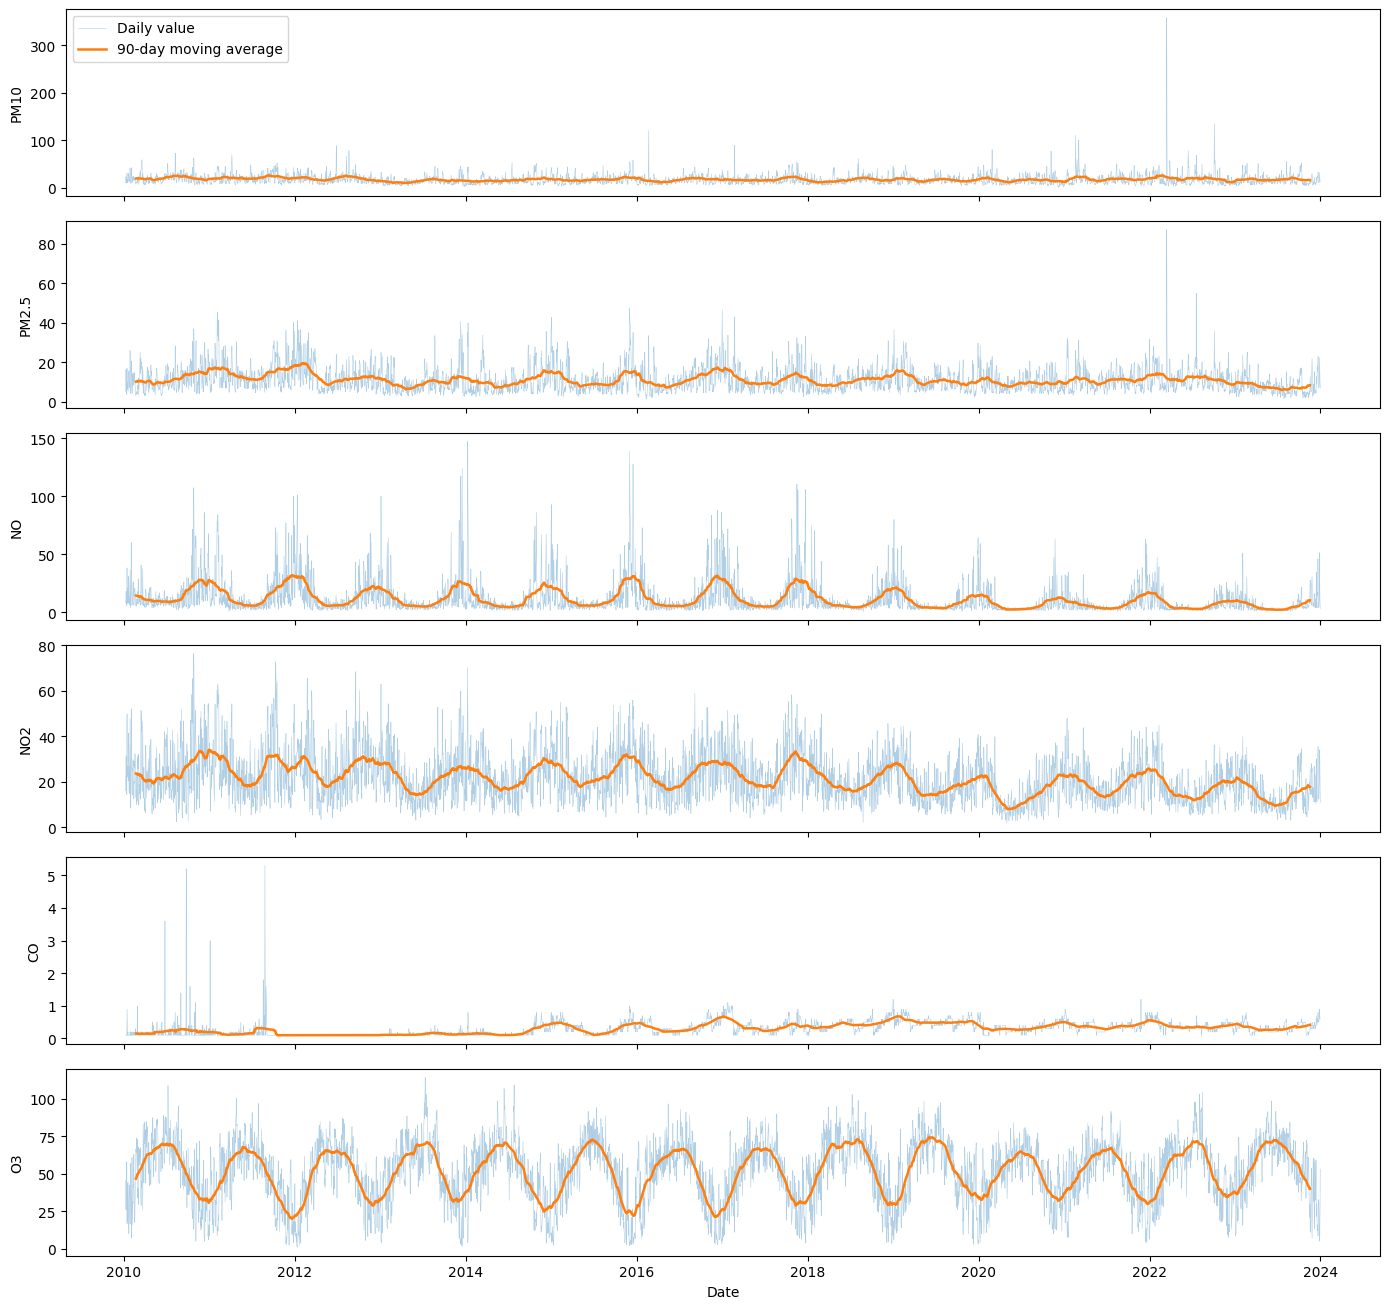

In [34]:
fig, axes = plt.subplots(
    len(POLLUTION_LAG0_COLS),
    1,
    figsize=(
        14,
        len(POLLUTION_LAG0_COLS) * 2.2,
    ),
    sharex=True,
)

for ax, col in zip(
    axes,
    POLLUTION_LAG0_COLS,
):
    ax.plot(
        df[DATE_COLUMN],
        df[col],
        linewidth=0.4,
        alpha=0.35,
        label="Daily value",
    )

    ax.plot(
        df[DATE_COLUMN],
        df[col]
        .rolling(90, center=True)
        .mean(),
        linewidth=1.8,
        label="90-day moving average",
    )

    ax.set_ylabel(
        POLLUTION_LABELS[col]
    )

axes[0].legend()
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 15. Monthly pollutant profiles

Monthly mean concentrations are calculated to visualise recurring seasonal patterns in air pollution.

In [35]:
monthly_pollution = (
    df
    .groupby("month")[
        POLLUTION_LAG0_COLS
    ]
    .mean()
)

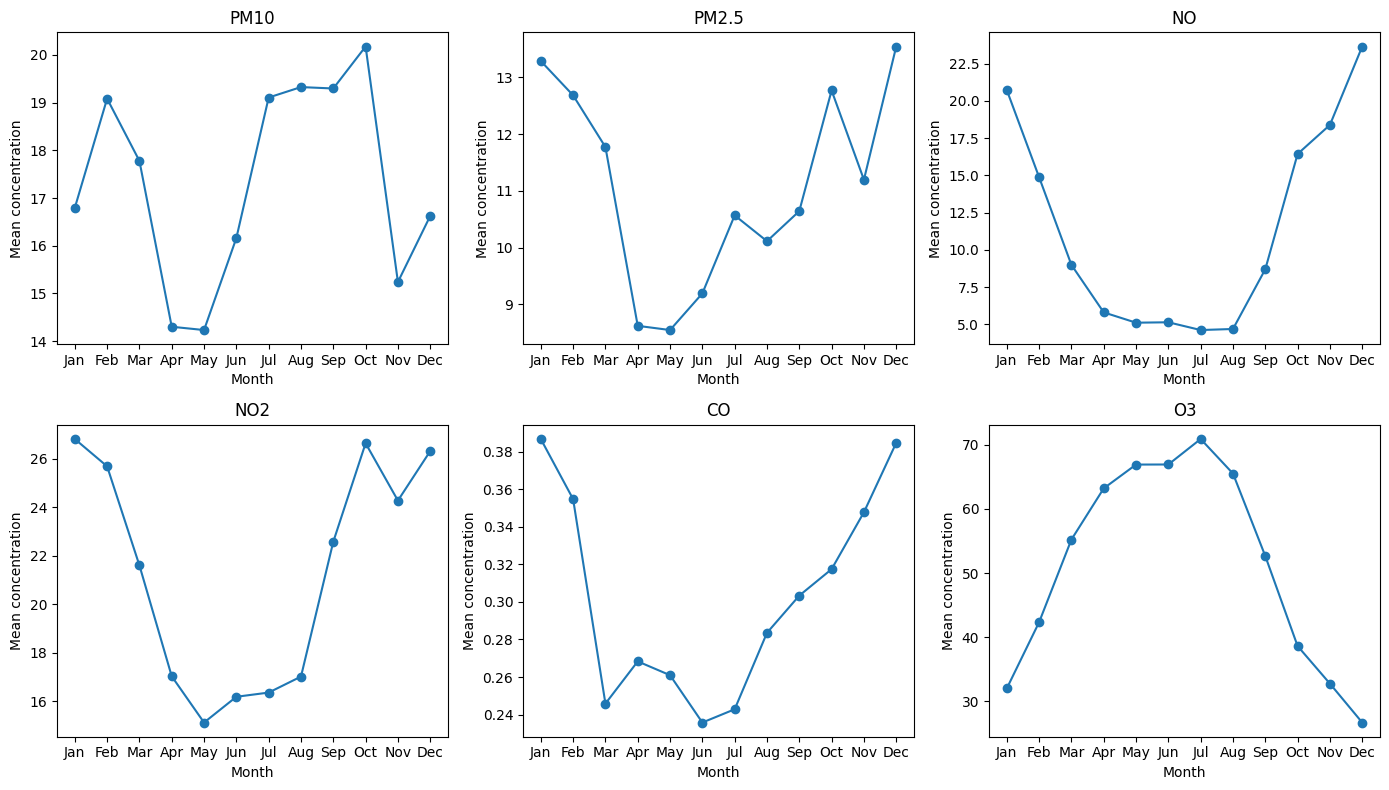

In [36]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

axes = axes.flatten()

for ax, col in zip(
    axes,
    POLLUTION_LAG0_COLS,
):
    ax.plot(
        MONTH_LABELS,
        monthly_pollution[col],
        marker="o",
    )

    ax.set_title(
        POLLUTION_LABELS[col]
    )
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean concentration")

plt.tight_layout()
plt.show()

## 16. Meteorological variables

Meteorological variables are analysed using their same-day values (`LAG0`).

The analysis includes:

- descriptive statistics;
- comparison between days with and without COPD-related emergency visits;
- distribution of daily values;
- temporal evolution;
- monthly seasonal profiles.

Temperature and thermal sensation are expressed in °C, atmospheric pressure in hPa, precipitation in mm, sunshine duration in hours, wind speed in km/h, and relative humidity in %.

In [37]:
METEOROLOGICAL_LABELS = {
    "temp_min_LAG0": "Minimum temperature",
    "temp_med_LAG0": "Mean temperature",
    "temp_max_LAG0": "Maximum temperature",
    "temp_sens_LAG0": "Thermal sensation",
    "pres_min_LAG0": "Minimum pressure",
    "pres_med_LAG0": "Mean pressure",
    "pres_max_LAG0": "Maximum pressure",
    "prec_24_LAG0": "24-h precipitation",
    "sol_24_LAG0": "24-h sunshine",
    "vel_med_LAG0": "Mean wind speed",
    "vel_max_LAG0": "Maximum wind speed",
    "hume_med_LAG0": "Mean humidity",
    "hume_max_LAG0": "Maximum humidity",
}

## 17. Descriptive statistics and comparison by target

In [38]:
meteorological_summary = descriptive_summary(
    df,
    METEOROLOGICAL_LAG0_COLS,
)

meteorological_summary = (
    meteorological_summary.rename(
        index=METEOROLOGICAL_LABELS
    )
)

meteorological_mannwhitney = {}

for col in METEOROLOGICAL_LAG0_COLS:
    group_negative = df.loc[
        df["target"] == 0,
        col,
    ]

    group_positive = df.loc[
        df["target"] == 1,
        col,
    ]

    statistic, p_value = mannwhitneyu(
        group_negative,
        group_positive,
        alternative="two-sided",
    )

    meteorological_mannwhitney[
        METEOROLOGICAL_LABELS[col]
    ] = p_value

meteorological_summary["p_value"] = pd.Series(
    meteorological_mannwhitney
)

meteorological_summary["Significant"] = (
    meteorological_summary["p_value"]
    < 0.05
)

meteorological_summary.round(4)

,Mean,SD,Median,IQR,Min,Max,p_value,Significant
Minimum temperature,7.4552,6.0962,7.50,9.8000,-7.8,23.50,0.0000,True
Mean temperature,13.5097,7.4009,13.00,12.3375,-3.6,31.90,0.0000,True
Maximum temperature,19.5992,9.1062,18.90,15.3000,-1.1,41.10,0.0000,True
Thermal sensation,11.6324,7.7412,10.80,12.4000,-6.3,31.30,0.0000,True
Minimum pressure,930.8471,7.0151,931.40,7.5000,891.7,955.50,0.2681,False
Mean pressure,933.1349,6.4545,933.40,7.2000,899.0,957.05,0.0645,False
Maximum pressure,935.3933,6.1214,935.50,6.8000,906.3,958.60,0.0047,True
24-h precipitation,1.1384,3.3772,0.00,0.2000,0.0,60.40,0.0397,True
24-h sunshine,7.4442,4.2020,8.30,7.2000,0.0,14.40,0.0000,True
Mean wind speed,7.2697,3.8561,6.12,3.9600,0.0,32.04,0.2442,False


## 18. Meteorological distributions

The distributions of the meteorological variables are examined to characterise their variability and identify variables with strongly asymmetric or bounded distributions.

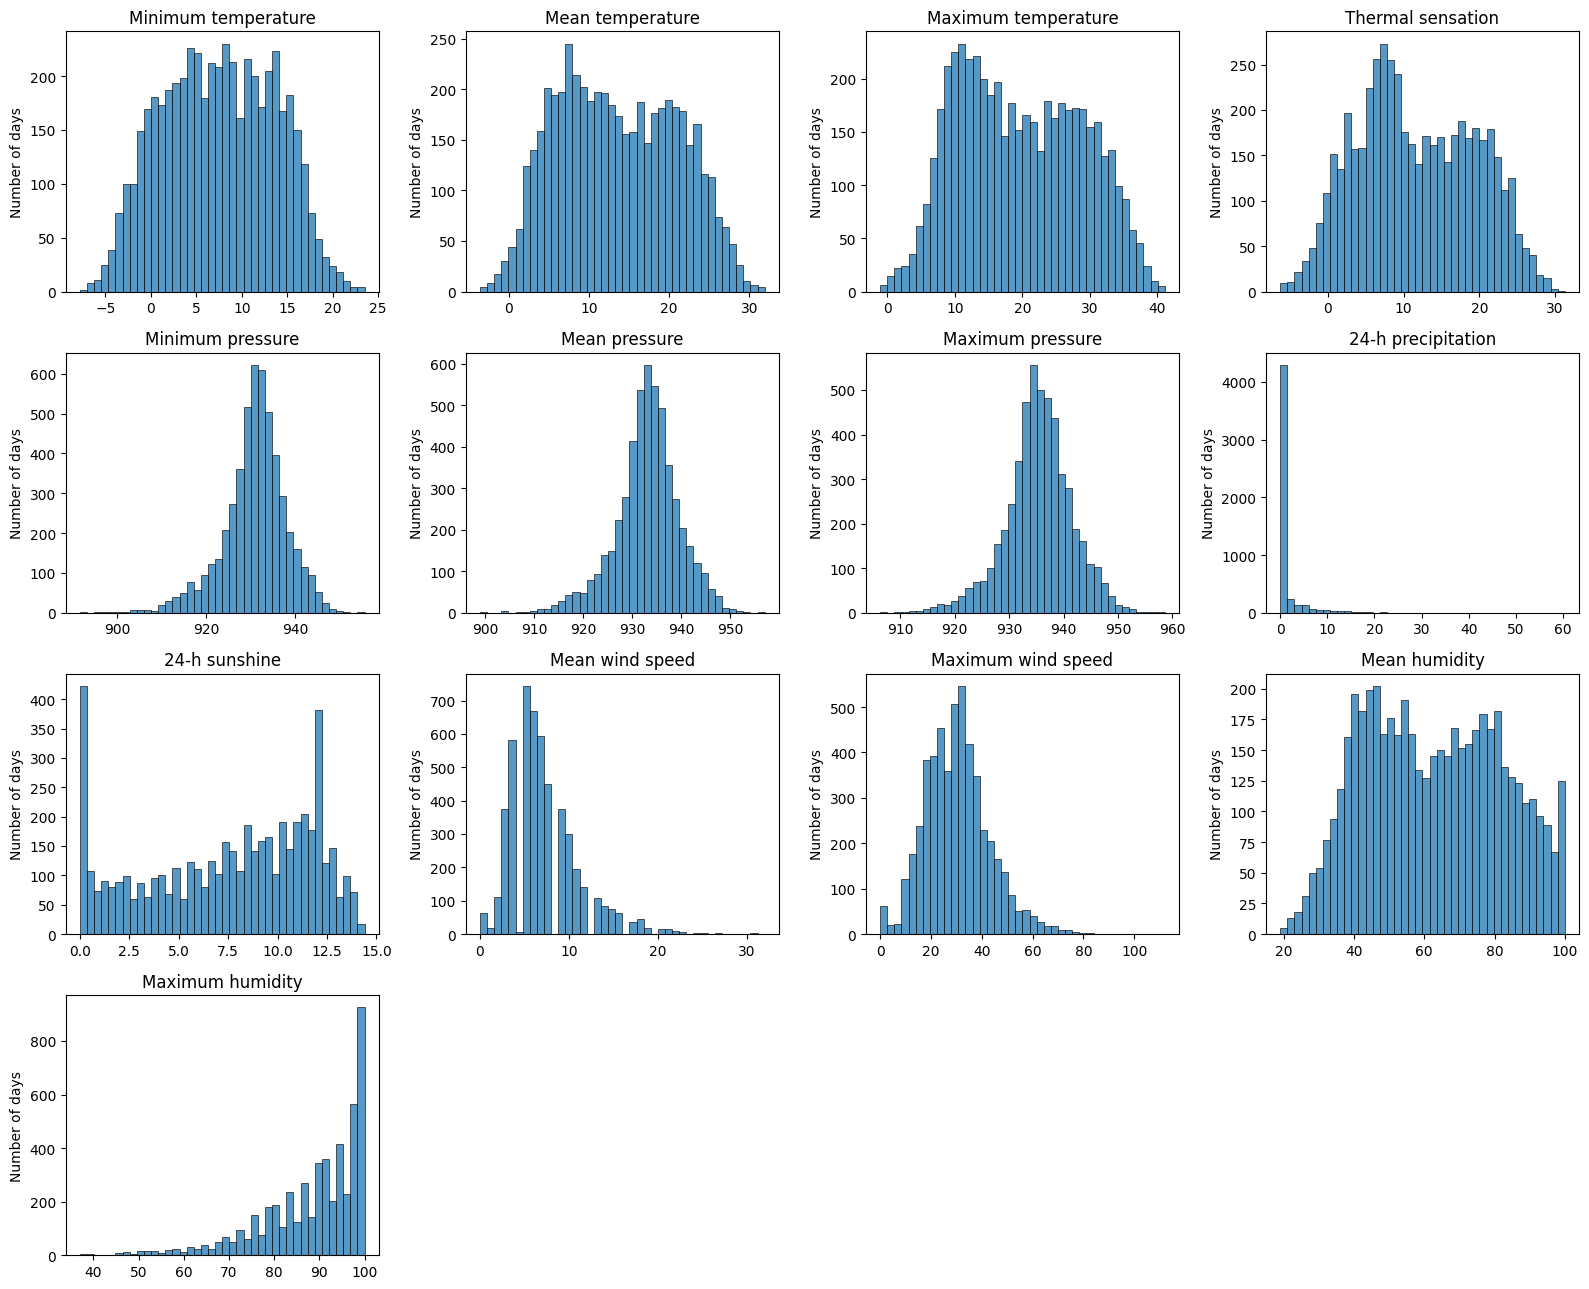

In [39]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(16, 13),
)

axes = axes.flatten()

for ax, col in zip(
    axes,
    METEOROLOGICAL_LAG0_COLS,
):
    sns.histplot(
        data=df,
        x=col,
        bins=40,
        ax=ax,
    )

    ax.set_title(
        METEOROLOGICAL_LABELS[col]
    )

    ax.set_xlabel("")
    ax.set_ylabel("Number of days")

# Hide unused axes
for ax in axes[
    len(METEOROLOGICAL_LAG0_COLS):
]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 19. Temporal evolution of meteorological variables

Daily meteorological observations are shown together with centred 90-day moving averages to highlight long-term and seasonal behaviour.

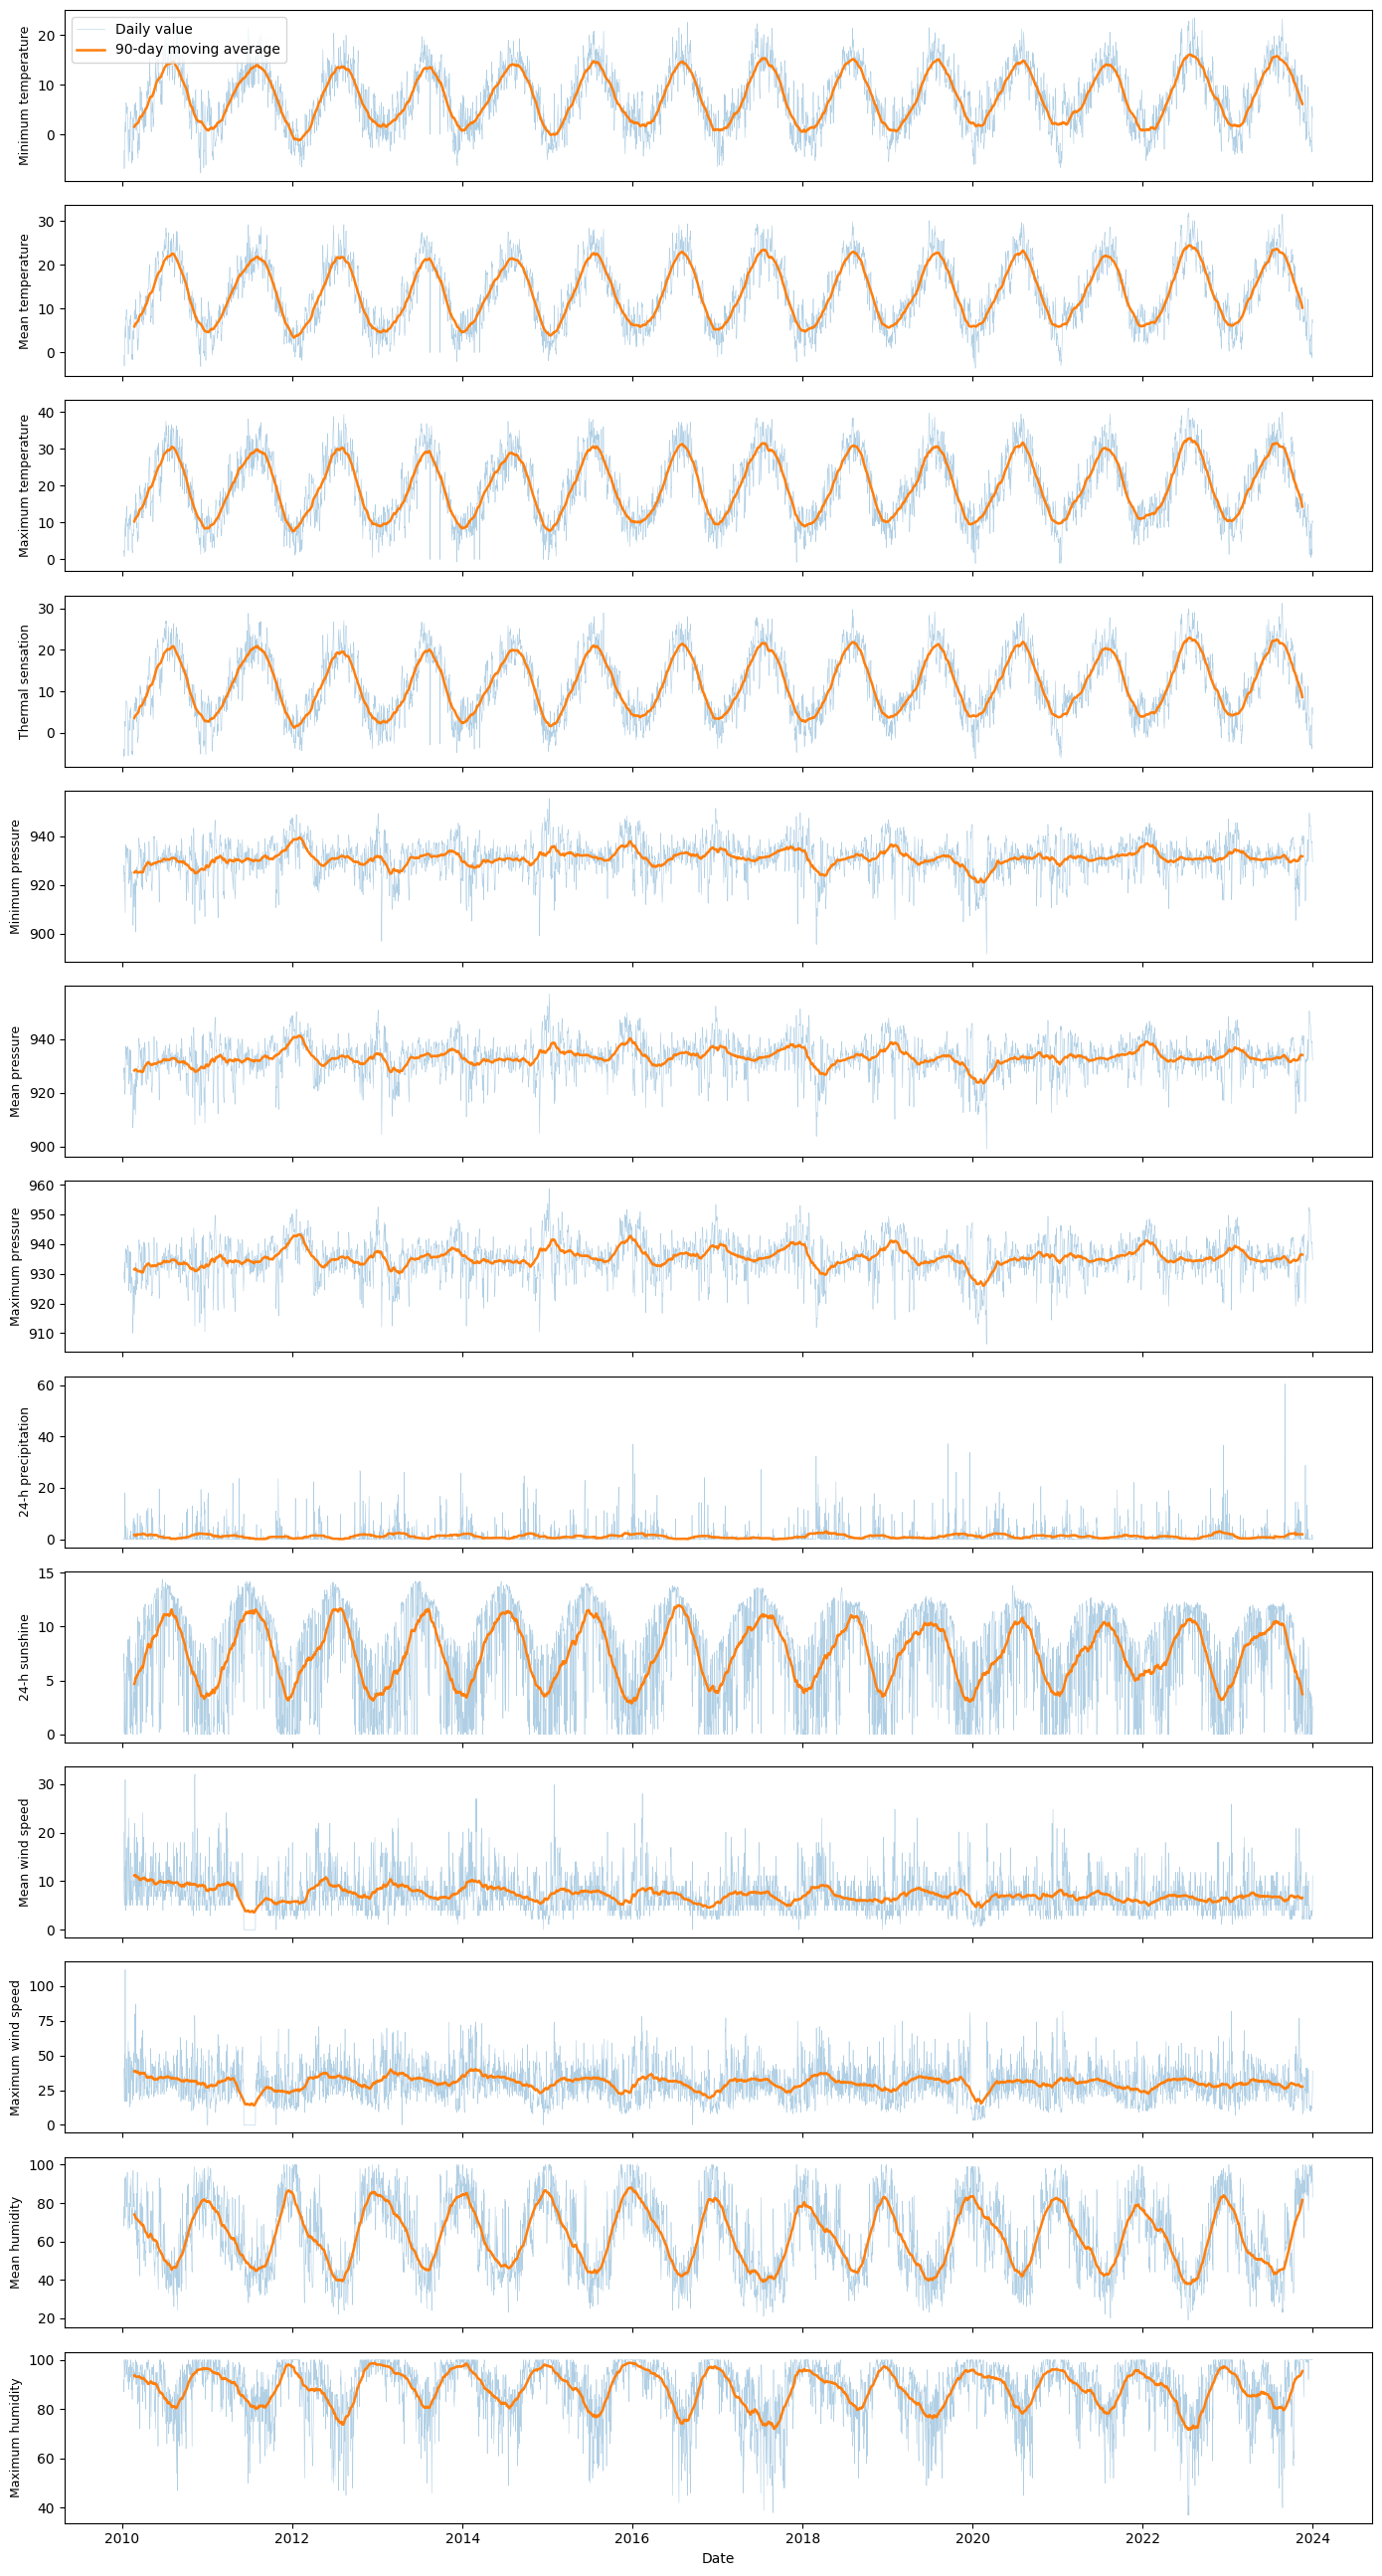

In [40]:
fig, axes = plt.subplots(
    len(METEOROLOGICAL_LAG0_COLS),
    1,
    figsize=(
        14,
        len(METEOROLOGICAL_LAG0_COLS) * 2,
    ),
    sharex=True,
)

for ax, col in zip(
    axes,
    METEOROLOGICAL_LAG0_COLS,
):
    ax.plot(
        df[DATE_COLUMN],
        df[col],
        linewidth=0.4,
        alpha=0.35,
        label="Daily value",
    )

    ax.plot(
        df[DATE_COLUMN],
        df[col]
        .rolling(90, center=True)
        .mean(),
        linewidth=1.8,
        label="90-day moving average",
    )

    ax.set_ylabel(
        METEOROLOGICAL_LABELS[col],
        fontsize=9,
    )

axes[0].legend()
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 20. Monthly meteorological profiles

Monthly mean values are used to visualise recurring seasonal patterns across the meteorological variables.

In [41]:
monthly_meteorology = (
    df
    .groupby("month")[
        METEOROLOGICAL_LAG0_COLS
    ]
    .mean()
)

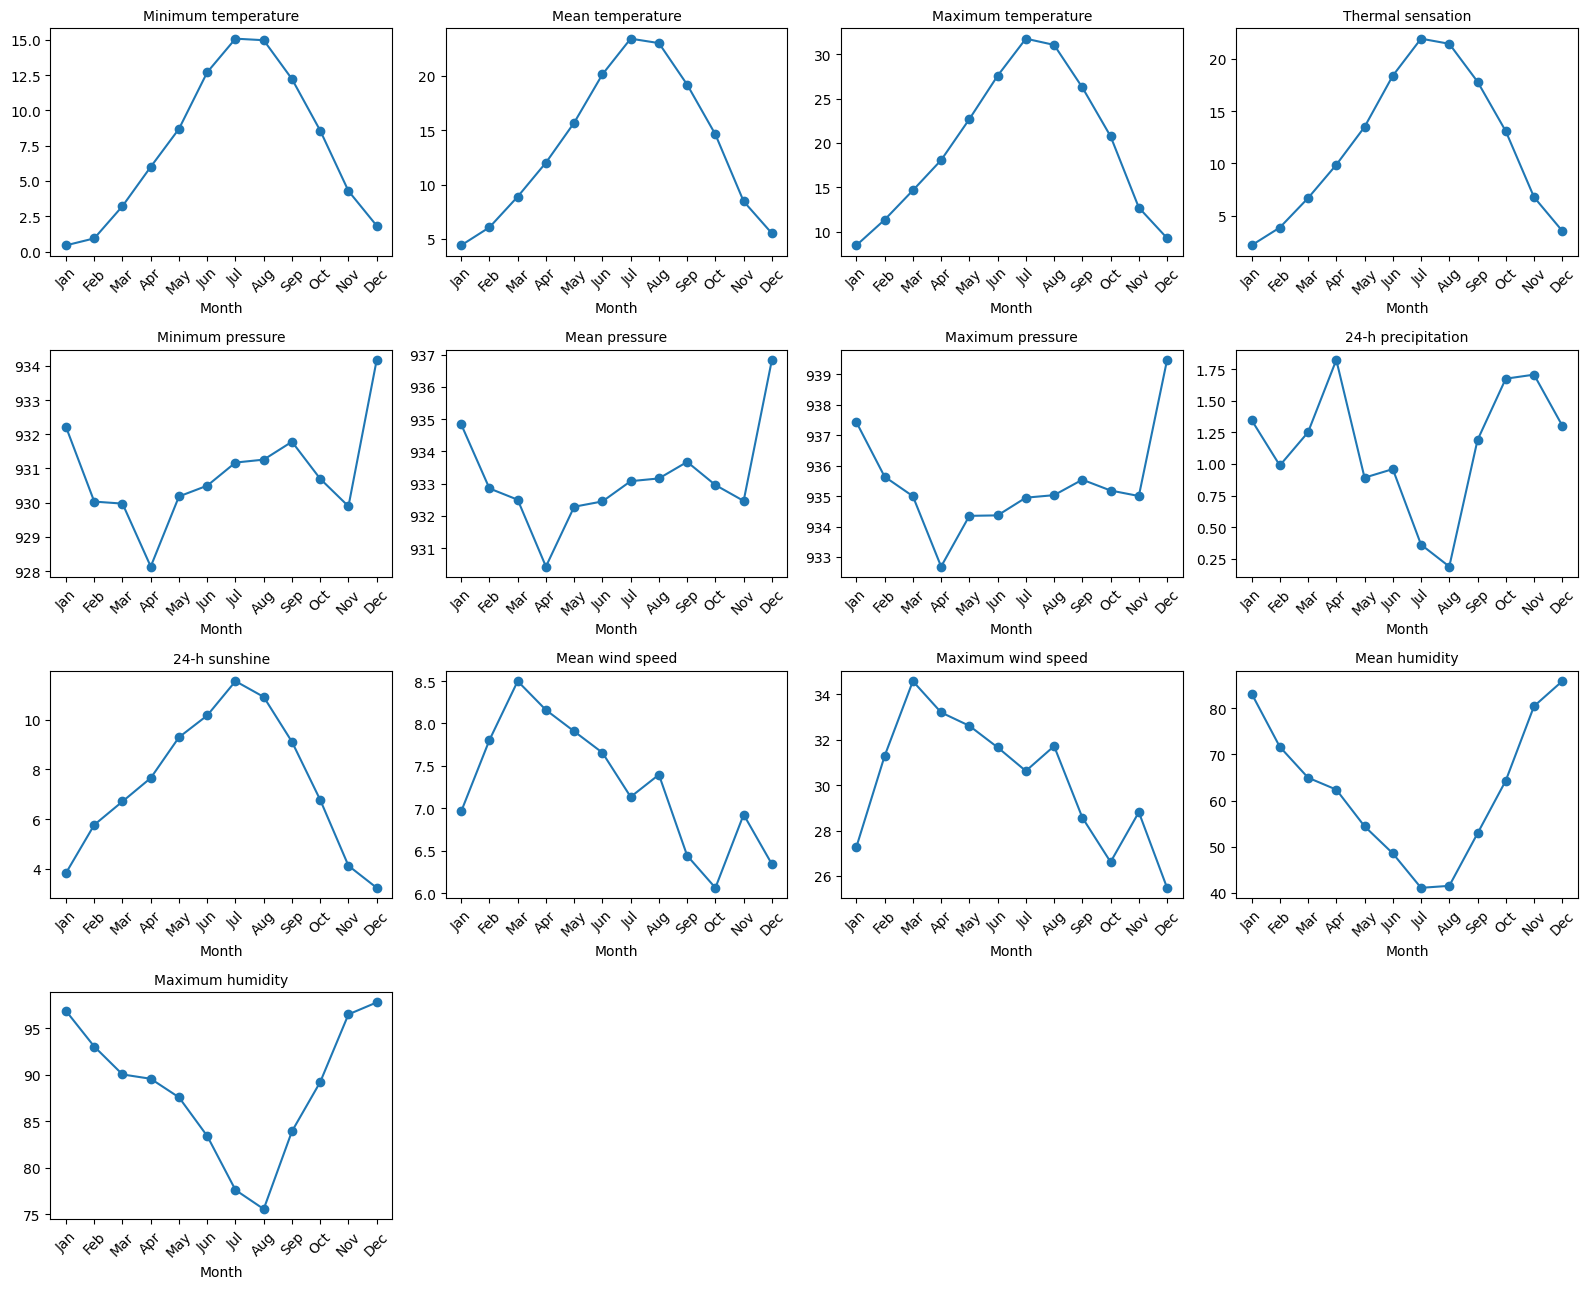

In [42]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(16, 13),
)

axes = axes.flatten()

for ax, col in zip(
    axes,
    METEOROLOGICAL_LAG0_COLS,
):
    ax.plot(
        MONTH_LABELS,
        monthly_meteorology[col],
        marker="o",
    )

    ax.set_title(
        METEOROLOGICAL_LABELS[col],
        fontsize=10,
    )

    ax.set_xlabel("Month")

    ax.tick_params(
        axis="x",
        rotation=45,
    )

for ax in axes[
    len(METEOROLOGICAL_LAG0_COLS):
]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 21. Interannual variability

The distributions of same-day environmental variables (`LAG0`) are compared across years using the non-parametric Kruskal–Wallis test.

The null hypothesis assumes that the distributions are equivalent across all years. A significant result indicates that at least one year differs from the others, but does not identify which years differ or the direction of the difference.

In [43]:
ENVIRONMENTAL_LAG0_COLS = (
    POLLUTION_LAG0_COLS
    + METEOROLOGICAL_LAG0_COLS
)

years = sorted(
    df["year"].unique()
)

kruskal_results = []

for col in ENVIRONMENTAL_LAG0_COLS:
    yearly_groups = [
        df.loc[
            df["year"] == year,
            col,
        ].dropna().values
        for year in years
    ]

    statistic, p_value = kruskal(
        *yearly_groups
    )

    kruskal_results.append(
        {
            "Variable": col,
            "KW_statistic": statistic,
            "p_value": p_value,
            "Significant": p_value < 0.05,
        }
    )

kruskal_results = (
    pd.DataFrame(kruskal_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

print(
    "Variables with significant interannual "
    f"differences: "
    f"{kruskal_results['Significant'].sum()}/"
    f"{len(kruskal_results)}"
)

kruskal_results

Variables with significant interannual differences: 19/19


,Variable,KW_statistic,p_value,Significant
0,CO_LAG0,2646.662352,0.000000e+00,True
1,NO_LAG0,706.739568,1.248211e-142,True
2,NO2_LAG0,529.974400,6.238964e-105,True
3,PM2p5_LAG0,352.007515,2.933575e-67,True
4,vel_med_LAG0,272.430910,1.377739e-50,True
5,pres_max_LAG0,226.369903,5.040226e-41,True
6,PM10_LAG0,220.871715,6.889316e-40,True
7,pres_med_LAG0,219.440337,1.360227e-39,True
8,pres_min_LAG0,208.116460,2.932436e-37,True
9,hume_max_LAG0,166.967515,7.625561e-29,True


## 22. Pairwise interannual comparisons

For environmental variables with a significant Kruskal–Wallis result, pairwise Mann–Whitney U tests are performed between all pairs of years.

Bonferroni correction is applied independently within each variable to control for multiple comparisons.

In [44]:
significant_variables = (
    kruskal_results.loc[
        kruskal_results["Significant"],
        "Variable",
    ]
    .tolist()
)

year_pairs = list(
    combinations(
        years,
        2,
    )
)

pairwise_records = []

for col in significant_variables:
    raw_p_values = []

    for year_1, year_2 in year_pairs:
        group_1 = df.loc[
            df["year"] == year_1,
            col,
        ].dropna()

        group_2 = df.loc[
            df["year"] == year_2,
            col,
        ].dropna()

        _, p_value = mannwhitneyu(
            group_1,
            group_2,
            alternative="two-sided",
        )

        raw_p_values.append(
            p_value
        )

    reject, corrected_p_values, _, _ = (
        multipletests(
            raw_p_values,
            method="bonferroni",
        )
    )

    for (
        year_1,
        year_2,
    ), corrected_p, significant in zip(
        year_pairs,
        corrected_p_values,
        reject,
    ):
        pairwise_records.append(
            {
                "Variable": col,
                "Year_1": year_1,
                "Year_2": year_2,
                "Corrected_p": corrected_p,
                "Significant": significant,
            }
        )

pairwise_results = pd.DataFrame(
    pairwise_records
)

pairwise_results.head()

,Variable,Year_1,Year_2,Corrected_p,Significant
0,CO_LAG0,2010,2011,2.756844e-04,True
1,CO_LAG0,2010,2012,1.049309e-38,True
2,CO_LAG0,2010,2013,6.470259e-05,True
3,CO_LAG0,2010,2014,1.000000e+00,False
4,CO_LAG0,2010,2015,8.401756e-30,True


In [45]:
significant_by_year = (
    pairwise_results.loc[
        pairwise_results["Significant"]
    ]
    .melt(
        id_vars=[
            "Variable",
            "Significant",
        ],
        value_vars=[
            "Year_1",
            "Year_2",
        ],
        value_name="Year",
    )
    .groupby("Year")[
        "Significant"
    ]
    .sum()
    .sort_index()
)

significant_by_year

Year
2010    111
2011     85
2012     72
2013     98
2014     86
2015     66
2016     53
2017     94
2018     67
2019     80
2020     98
2021     66
2022     80
2023     82
Name: Significant, dtype: int64

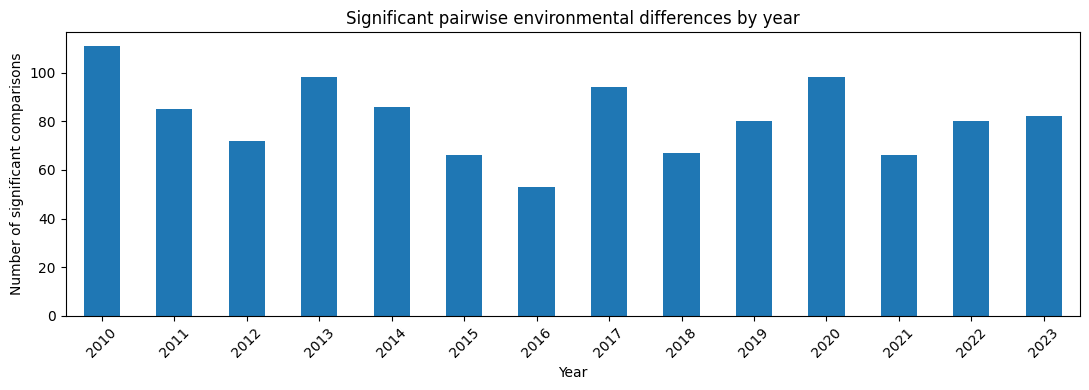

In [46]:
fig, ax = plt.subplots(
    figsize=(11, 4)
)

significant_by_year.plot(
    kind="bar",
    ax=ax,
)

ax.set_title(
    "Significant pairwise environmental differences by year"
)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Number of significant comparisons"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

plt.tight_layout()
plt.show()

## 23. Correlation between environmental variables

Spearman rank correlation is used to explore monotonic associations and redundancy among same-day environmental variables.

Three correlation structures are examined:

- correlations among air pollutants;
- correlations among meteorological variables;
- cross-correlations between meteorological variables and pollutants.

These associations are descriptive and should not be interpreted as causal relationships.

## 24. Correlations among air pollutants

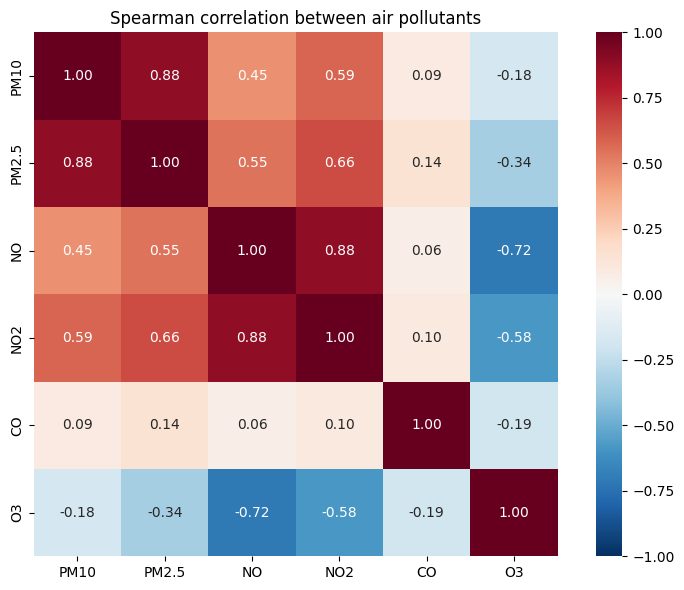

In [47]:
pollution_corr = (
    df[POLLUTION_LAG0_COLS]
    .corr(
        method="spearman"
    )
)

pollution_corr = pollution_corr.rename(
    index=POLLUTION_LABELS,
    columns=POLLUTION_LABELS,
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

sns.heatmap(
    pollution_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    square=True,
    ax=ax,
)

ax.set_title(
    "Spearman correlation between air pollutants"
)

plt.tight_layout()
plt.show()

## 25. Correlations among meteorological variables

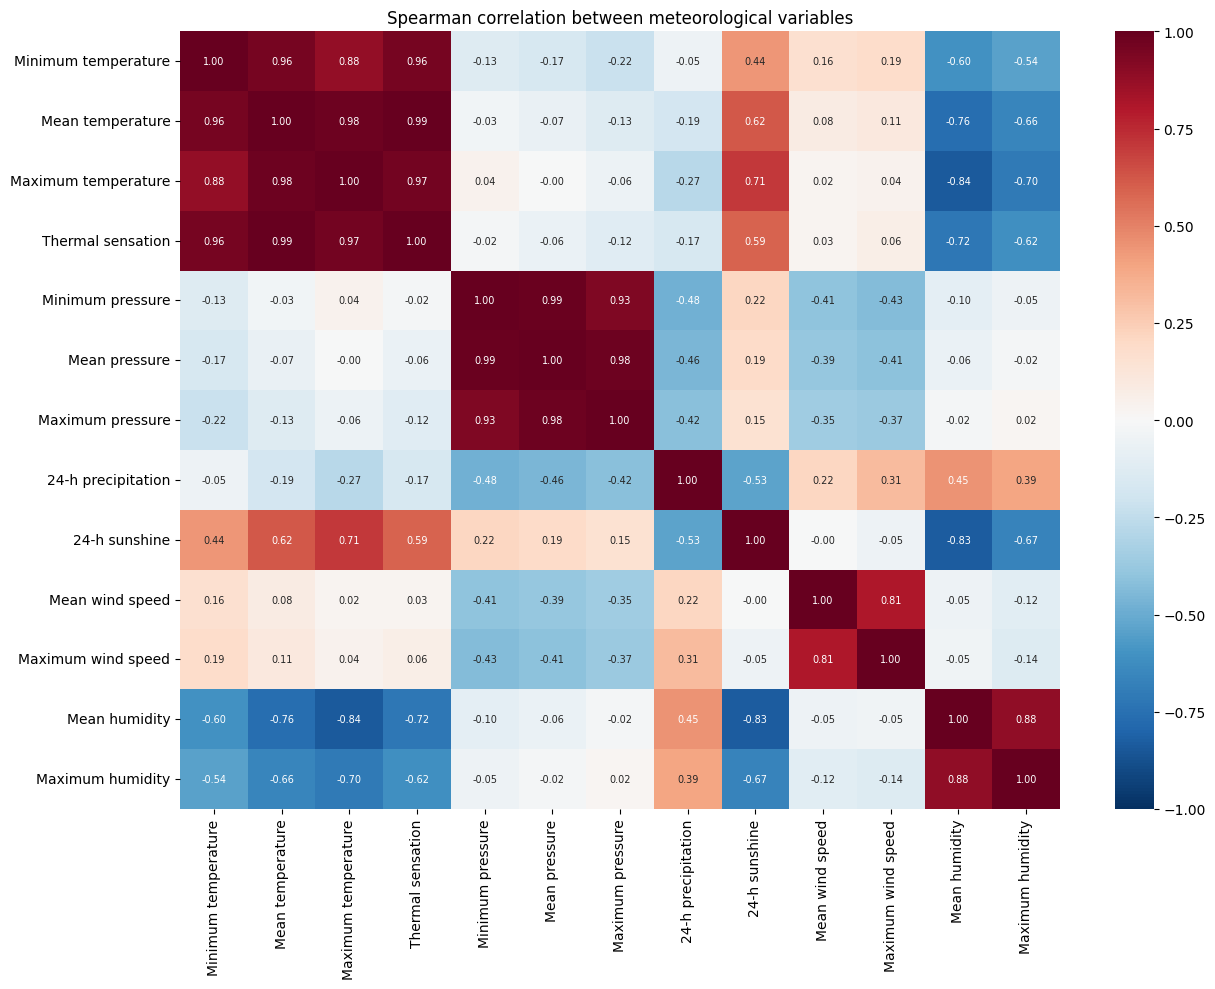

In [48]:
meteorological_corr = (
    df[METEOROLOGICAL_LAG0_COLS]
    .corr(
        method="spearman"
    )
)

meteorological_corr = (
    meteorological_corr.rename(
        index=METEOROLOGICAL_LABELS,
        columns=METEOROLOGICAL_LABELS,
    )
)

fig, ax = plt.subplots(
    figsize=(13, 10)
)

sns.heatmap(
    meteorological_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    annot_kws={
        "size": 7,
    },
    ax=ax,
)

ax.set_title(
    "Spearman correlation between meteorological variables"
)

plt.tight_layout()
plt.show()

## 26. Pollution–meteorology correlations

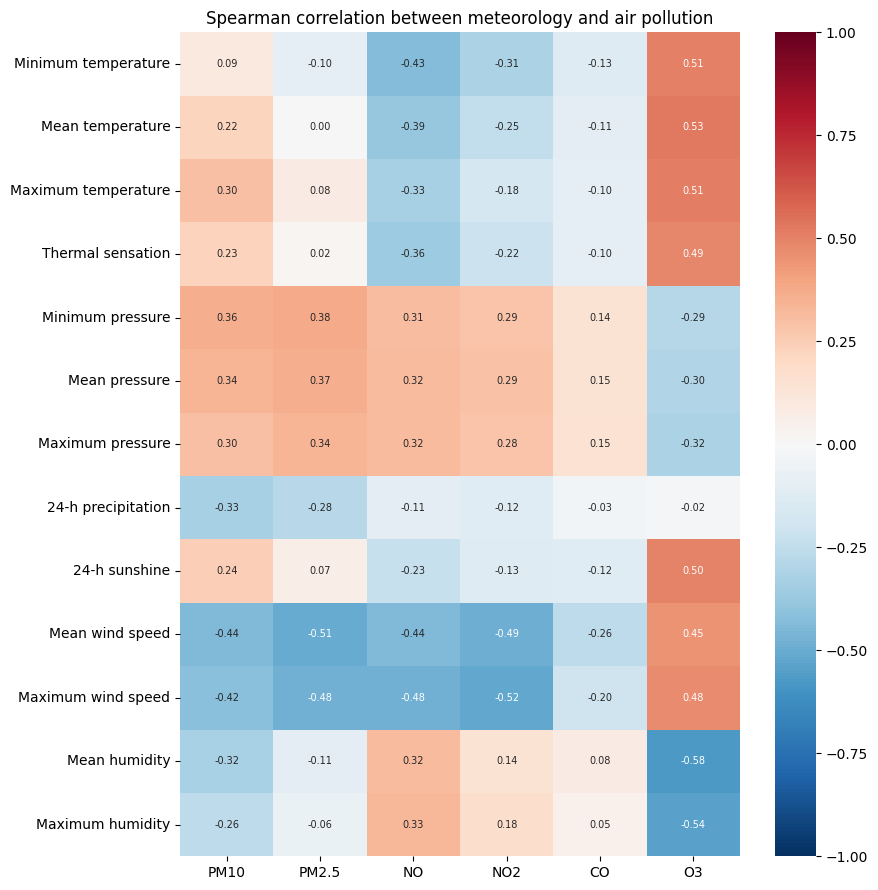

In [49]:
cross_corr = (
    df[
        METEOROLOGICAL_LAG0_COLS
        + POLLUTION_LAG0_COLS
    ]
    .corr(
        method="spearman"
    )
    .loc[
        METEOROLOGICAL_LAG0_COLS,
        POLLUTION_LAG0_COLS,
    ]
)

cross_corr = cross_corr.rename(
    index=METEOROLOGICAL_LABELS,
    columns=POLLUTION_LABELS,
)

fig, ax = plt.subplots(
    figsize=(9, 9)
)

sns.heatmap(
    cross_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    annot_kws={
        "size": 7,
    },
    ax=ax,
)

ax.set_title(
    "Spearman correlation between meteorology and air pollution"
)

plt.tight_layout()
plt.show()

## 27. Exploratory analysis summary

The exploratory analysis highlights several characteristics relevant to the subsequent predictive modelling stage:

- daily COPD-related emergency demand is low, with most observations concentrated at 0–1 visits;
- the binary target is comparatively balanced, with approximately 55% positive days;
- emergency demand shows clear seasonal variation, with higher values during colder months;
- marked changes are visible during 2020–2021;
- visits are more frequent among men and patients aged 65 years or older;
- several air pollutants show strongly skewed distributions and clear seasonal patterns;
- ozone displays a seasonal pattern opposite to nitrogen oxides and some particulate-matter variables;
- meteorological variables exhibit substantial seasonal structure;
- all analysed environmental variables show evidence of interannual distributional changes;
- strong correlations exist among related environmental predictors, particularly PM10–PM2.5 and NO–NO2.

These findings motivate the temporal validation strategy and the subsequent feature-engineering and redundancy-reduction stages.